# Лабораторная работа №9
## *Реализация алгоритма Гриффина-Лима*
по курсу Цифровая обработка сигналов  
  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Рыбин Сергей Витальевич  
**выполнили:** Иванова Мария Кирилловна  
**группа:** М4121

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy import signal


### Загрузка и воспроизведение исходного сигнала*

In [3]:
def draw_waveform(y, sr=44100, title="Waveform"):

    t = np.arange(len(y)) / sr

    plt.figure(figsize=(14, 4))
    plt.plot(t, y, color="#A1B7F4")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

Len is 527789. Sample rate is 44100
Исходная частота дискретизации: 44100


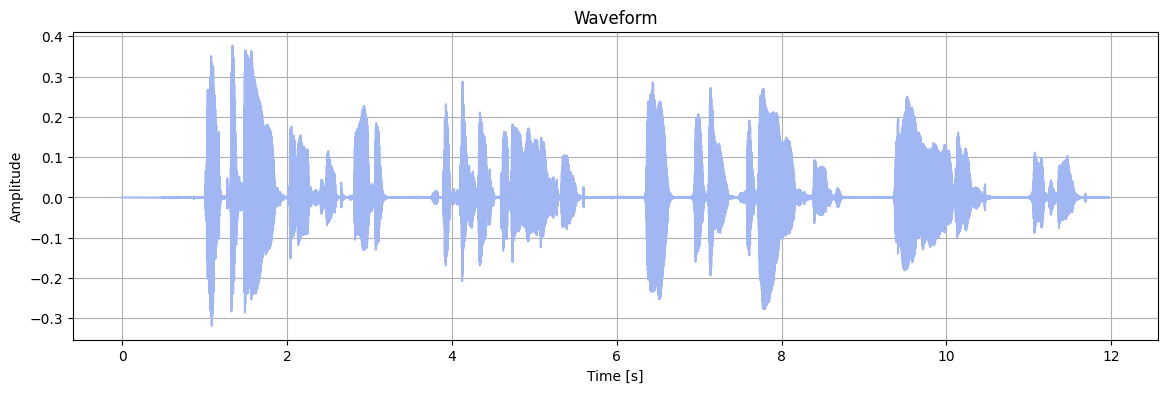

In [ ]:
signal, sr = librosa.core.load('./Recording_1.wav', sr=None)
print(f"Len is {len(signal)}. Sample rate is {sr}")
print("Исходная частота дискретизации:", sr)
player = ipd.Audio(signal, rate=sr)
ipd.display(player)
draw_waveform(signal, sr=sr)

### Реализация преэмфазиса

In [5]:
def preemphasis(signal, pre_emphasis=0.97):

    emphasized_signal = np.zeros_like(signal)
    
    emphasized_signal[0] = signal[0]

    for n in range(1, len(signal)):
        emphasized_signal[n] = signal[n] - pre_emphasis * signal[n-1]    

    return emphasized_signal

### Тестирование функции преэмфазиса

In [6]:
emphasized_signal = preemphasis(signal)

C:\Users\Landi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


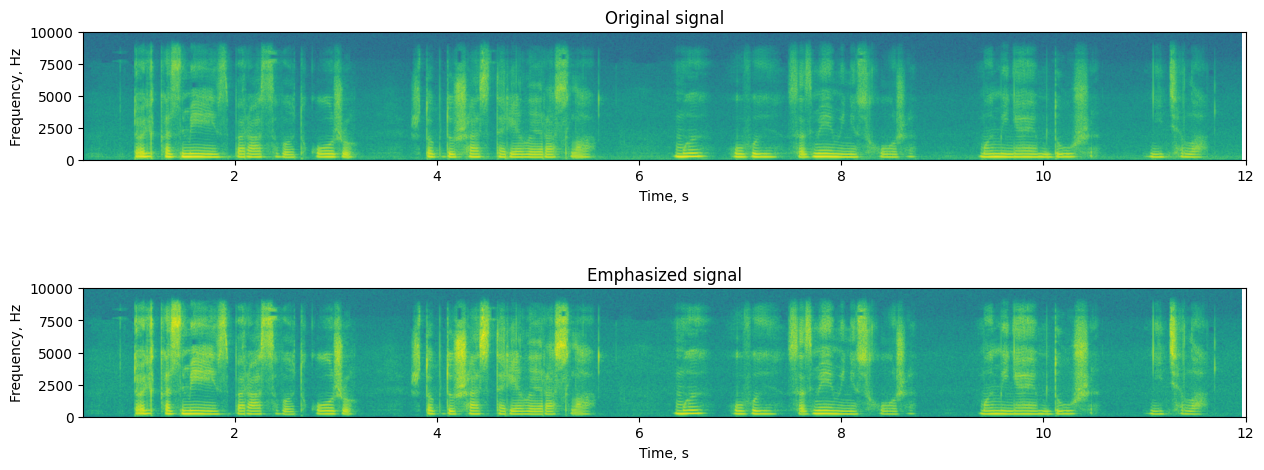

In [7]:
plt.figure(figsize=(15, 5))
plot_a = plt.subplot(211)
plt.subplots_adjust(wspace=0, hspace=1)

plot_a.specgram(signal, NFFT=1024, Fs=sr, noverlap=900)
plot_a.set_xlabel('Time, s')
plot_a.set_ylabel('Frequency, Hz')
plot_a.title.set_text('Original signal')
plt.xlim(0.5, 12)
plt.ylim(0, 10000)

plot_b = plt.subplot(212)
plot_b.specgram(emphasized_signal, NFFT=1024, Fs=sr, noverlap=900)
plot_b.set_xlabel('Time, s')
plot_b.set_ylabel('Frequency, Hz')
plot_b.title.set_text('Emphasized signal')
plt.xlim(0.5, 12)
plt.ylim(0, 10000)
plt.show()

Область высоких частот становится ярче, что свидетельствует о большей сбаллансированности всех частот после процедуры преэмфазиса

In [8]:
# Загрузка и преэмфазис
def load_and_preprocess(file_path, sr_target=16000, pre_emphasis=0.97, trim_silence=True):

    y, sr = librosa.load(file_path, sr=sr_target)
    
    if trim_silence:
        y, _ = librosa.effects.trim(y)
    
    if pre_emphasis is not None:
        y = preemphasis(y, pre_emphasis)
    
    return y, sr

In [9]:
# Функция построения спектрограммы
def compute_spectrogram(y, n_fft=2048, hop_length=512):
    
    S_complex = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    S_magnitude = np.abs(S_complex)
    return S_complex, S_magnitude

### Реализация Алгоритм Гриффина-Лима

In [10]:
# Реализация алгоритма
def griffin_lim(magnitude_spectrogram, n_fft=2048, hop_length=512, n_iter=100):

    num_freq, num_frames = magnitude_spectrogram.shape
    phase = np.exp(2j * np.pi * np.random.rand(num_freq, num_frames))
    S = magnitude_spectrogram * phase
    
    for i in range(n_iter):
        y = librosa.istft(S, hop_length=hop_length, win_length=n_fft)
        S_new = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
        phase = np.exp(1j * np.angle(S_new))
        S = magnitude_spectrogram * phase
    
    # Реконструкция
    y_reconstructed = librosa.istft(S, hop_length=hop_length, win_length=n_fft)
    return y_reconstructed

In [11]:
# В случае преэмфазиса - обратная функция
def deemphasis(y, alpha=0.97):
    return signal.lfilter([1], [1, -alpha], y)

In [12]:
def compare_signals(original, reconstructed, sr, titles=("Original", "Reconstructed")):

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Временная область
    t_orig = np.arange(len(original)) / sr
    t_rec = np.arange(len(reconstructed)) / sr
    
    axes[0, 0].plot(t_orig, original, color='blue', alpha=0.7)
    axes[0, 0].set_title(titles[0])
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True)
    
    axes[0, 1].plot(t_rec, reconstructed, color='red', alpha=0.7)
    axes[0, 1].set_title(titles[1])
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].grid(True)
    
    # Спектрограммы
    axes[1, 0].specgram(original, NFFT=1024, Fs=sr, noverlap=512, cmap='viridis')
    axes[1, 0].set_title(f'{titles[0]} Spectrogram')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Frequency (Hz)')
    
    axes[1, 1].specgram(reconstructed, NFFT=1024, Fs=sr, noverlap=512, cmap='viridis')
    axes[1, 1].set_title(f'{titles[1]} Spectrogram')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Frequency (Hz)')
    
    plt.tight_layout()
    plt.show()


### Реализация эксперимента

In [13]:
def run_experiment(file_path, use_preemphasis=True, n_fft=2048, hop_length=512, n_iter=10):

    pre_emphasis_coef = 0.97 if use_preemphasis else None
    y, sr = load_and_preprocess(file_path, pre_emphasis=pre_emphasis_coef)
   
    S_complex, S_magnitude = compute_spectrogram(y, n_fft=n_fft, hop_length=hop_length)

    y_reconstructed = griffin_lim(S_magnitude, n_fft=n_fft, hop_length=hop_length, n_iter=n_iter)

    if use_preemphasis:
        y_reconstructed = deemphasis(y_reconstructed, alpha=0.97)

    
    # Визуализация
    compare_signals(y, y_reconstructed, sr, 
                    titles=("Original (with preemphasis)" if use_preemphasis else "Original", 
                            "Reconstructed (Griffin-Lim)"))
    
    # Воспроизведение сигналов
    print("Оригинальный сигнал:")
    ipd.display(ipd.Audio(y, rate=sr))
    print("Восстановленный сигнал:")
    ipd.display(ipd.Audio(y_reconstructed, rate=sr))
    
    return y, y_reconstructed, sr

### Запуск экспериментов

Эксперимент С преэмфазисом (α=0.97)


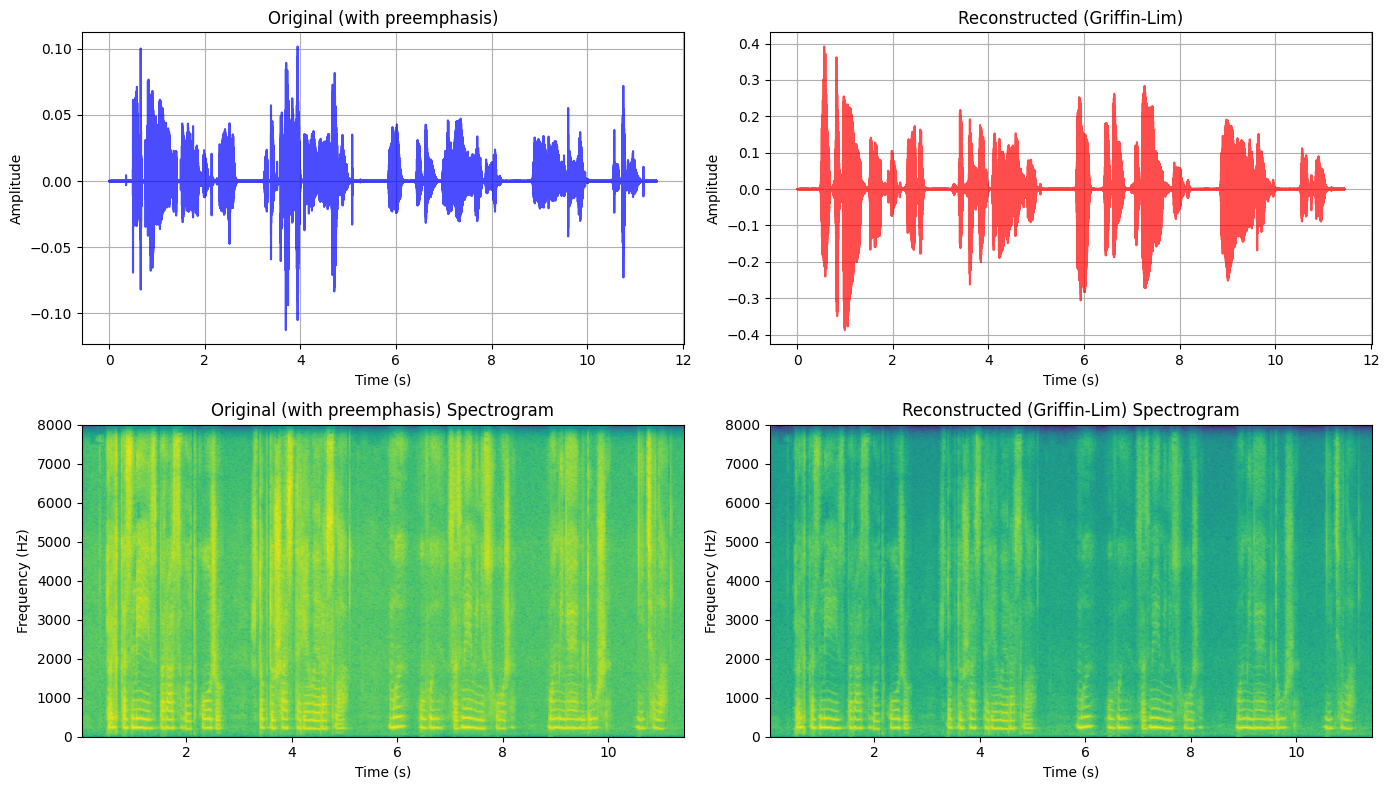

Оригинальный сигнал:


Восстановленный сигнал:


Эксперимент без преэмфазиса


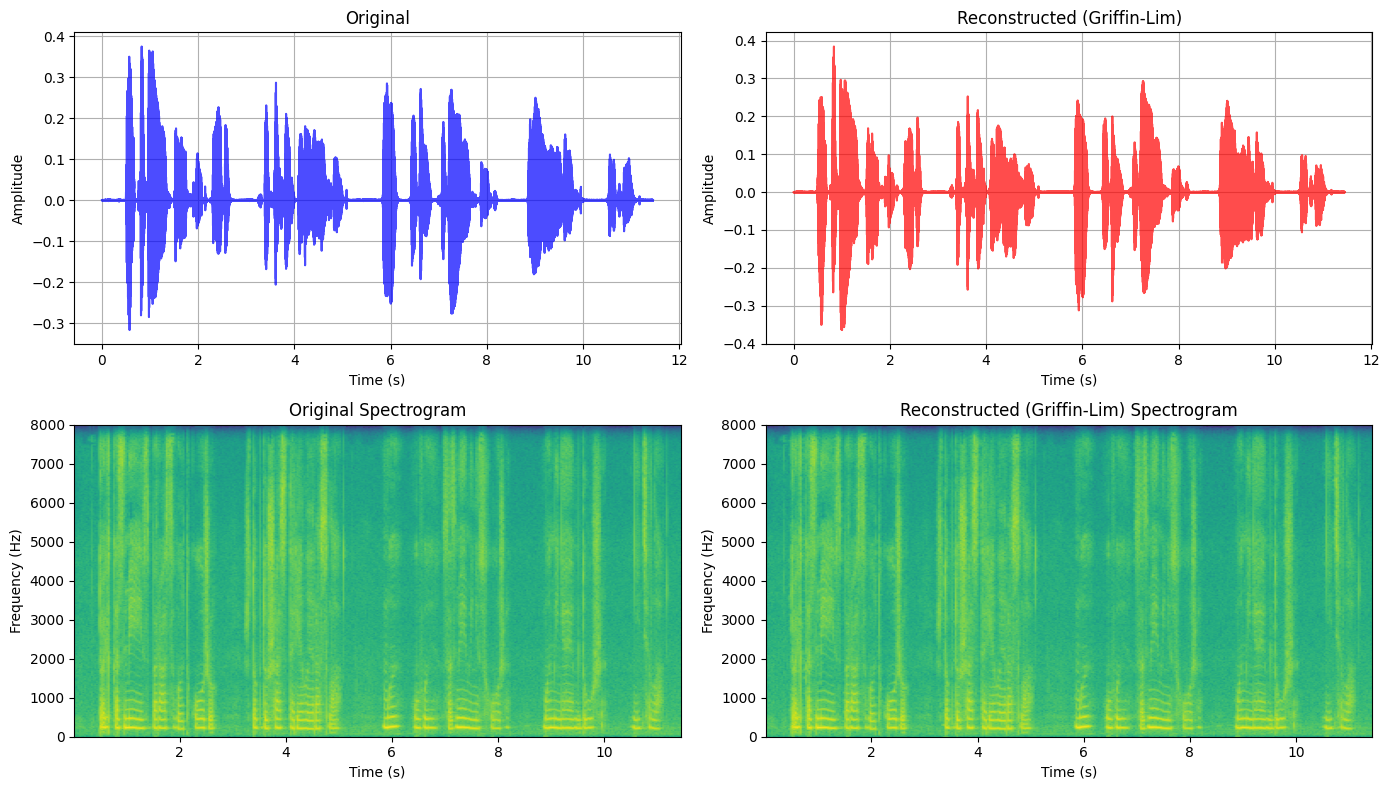

Оригинальный сигнал:


Восстановленный сигнал:


In [ ]:
if __name__ == "__main__":
    file_path = "./Recording_1.wav"
    
    # Эксперимент с преэмфазисом
    print("Эксперимент С преэмфазисом (α=0.97)")
    signal_with_pre, signal_rec_with_pre, sr = run_experiment(
        file_path, 
        use_preemphasis=True,
        n_fft=2048,
        hop_length=512,
        n_iter=100
    )
    
    # Эксперимент без преэмфазиса
    print("Эксперимент без преэмфазиса")
    signal_without_pre, signal_rec_without_pre, sr = run_experiment(
        file_path,
        use_preemphasis=False,
        n_fft=2048,
        hop_length=512,
        n_iter=100
    )

## Выводы

#### Эксперимент без преэмфазиса показывает лучшие результаты:
- Восстановленный с помощью алгоритма Гриффина-Лима сигнал практически неотличим от исходного как на слух, так и визуально
- Осциллограммы и спектрограммы оригинального и восстановленного сигналов практически идентичны
#### Эксперимент с преэмфазисом (α=0.97):
- Сигнал успешно восстанавливается, но заметно отличается от исходного
- Преэмфазис, хотя и улучшает соотношение сигнал/шум для высоких частот, вносит искажения, которые алгоритм не может полностью компенсировать
- Дополнительные преобразования сигнала усложняют задачу фазовой реконструкции

#### На слух разница между результатами при разном количестве итераций и разном размере ДПФ неслышна, можно пользоваться базовой настройкой.